## Lab 2 
author: "Thalie D-B"

# Accessing Data
This is data from the Framingham Heart Study. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/GauravPadawe/"
    "Framingham-Heart-Study/master/framingham.csv"
)

fram = pd.read_csv(DATA_URL, na_values=["NA", ""])

# View data structure

In [4]:
print(f"Rows: {fram.shape[0]:,}")
print(f"Columns: {fram.shape[1]}")
display(fram.head())

Rows: 4,240
Columns: 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
fram.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


# Check for missing values

In [6]:
missing = fram.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_n"))

,missing_n
glucose,388
education,105
BPMeds,53
totChol,50
cigsPerDay,29
BMI,19
heartRate,1


# Variable Analysis and Transformations
I chose to look at the variables for age, current smoker status and ten year CHD. I organized the data by creating age groups for age ranges and I created smoking status that translates the 0/1 data into no/yes, and established the display order. This is how I chose to display the data to make it easier to interpret.

In [7]:
analysis_vars = ["age", "currentSmoker", "TenYearCHD"]

for column in analysis_vars:
    print(f"\n{column}")
    print(fram[column].value_counts(dropna=False).sort_index())


age
age
32      1
33      5
34     18
35     42
36     84
37     92
38    144
39    170
40    192
41    174
42    180
43    159
44    166
45    162
46    182
47    141
48    173
49    132
50    140
51    146
52    149
53    139
54    132
55    145
56    123
57    123
58    117
59    119
60    111
61    110
62     99
63    110
64     93
65     57
66     38
67     45
68     18
69      7
70      2
Name: count, dtype: int64

currentSmoker
currentSmoker
0    2145
1    2095
Name: count, dtype: int64

TenYearCHD
TenYearCHD
0    3596
1     644
Name: count, dtype: int64


In [8]:
analysis = fram[analysis_vars].dropna().copy()

excluded_n = len(fram) - len(analysis)

print(f"Original participants: {len(fram):,}")
print(f"Analysis participants: {len(analysis):,}")
print(f"Participants excluded: {excluded_n}")

Original participants: 4,240
Analysis participants: 4,240
Participants excluded: 0


In [10]:
analysis["age_group"] = pd.cut(
    analysis["age"],
    bins=[30, 40, 50, 60, np.inf],
    labels=["Under 40", "40–49", "50–59", "60+"],
    right=False,
)

analysis["smoking_status"] = analysis["currentSmoker"].map(
    {0: "No", 1: "Yes"}
)

display(analysis.head())

,age,currentSmoker,TenYearCHD,age_group,smoking_status
0,39,0,0,Under 40,No
1,46,0,0,40–49,No
2,48,1,0,40–49,Yes
3,61,1,1,60+,Yes
4,46,1,0,40–49,Yes


In [11]:
print("Participants by age group:")
print(analysis["age_group"].value_counts(sort=False))

print("\nParticipants by smoking status:")
print(analysis["smoking_status"].value_counts())

Participants by age group:
age_group
Under 40     556
40–49       1661
50–59       1333
60+          690
Name: count, dtype: int64

Participants by smoking status:
smoking_status
No     2145
Yes    2095
Name: count, dtype: int64


In [12]:
smoking_order = ["No", "Yes"]

analysis["smoking_status"] = pd.Categorical(
    analysis["smoking_status"],
    categories=smoking_order,
    ordered=True,
)

# Ten Year CHD outcomes 
Using the age and smoke status variables, I calcuated CHD prevelance. I grouped participants by age group and smoking status. For each group, I calculated the total number of participants, the amount of participants with CHD, and the percentage of participants who got CHD. I also compared the prevalence of CHD outcomes for each age group based on smoking status.

In [13]:
summary = (
    analysis
    .groupby(["age_group", "smoking_status"], observed=True)
    .agg(
        n=("TenYearCHD", "size"),
        chd_cases=("TenYearCHD", "sum"),
        chd_prevalence=("TenYearCHD", "mean"),
    )
    .reset_index()
)

summary["chd_percent"] = 100 * summary["chd_prevalence"]

display(summary)

,age_group,smoking_status,n,chd_cases,chd_prevalence,chd_percent
0,Under 40,No,229,5,0.021834,2.183406
1,Under 40,Yes,327,18,0.055046,5.504587
2,40–49,No,677,47,0.069424,6.942393
3,40–49,Yes,984,120,0.121951,12.195122
4,50–59,No,763,132,0.173001,17.300131
5,50–59,Yes,570,131,0.229825,22.982456
6,60+,No,476,127,0.266807,26.680672
7,60+,Yes,214,64,0.299065,29.906542


In [14]:
summary_display = summary.copy()
summary_display["chd_prevalence"] = summary_display[
    "chd_prevalence"
].map(lambda value: f"{value:.1%}")

display(
    summary_display[
        ["age_group", "smoking_status", "n", "chd_cases", "chd_prevalence"]
    ]
)

,age_group,smoking_status,n,chd_cases,chd_prevalence
0,Under 40,No,229,5,2.2%
1,Under 40,Yes,327,18,5.5%
2,40–49,No,677,47,6.9%
3,40–49,Yes,984,120,12.2%
4,50–59,No,763,132,17.3%
5,50–59,Yes,570,131,23.0%
6,60+,No,476,127,26.7%
7,60+,Yes,214,64,29.9%


In [15]:
print(f"Participants represented: {summary['n'].sum():,}")
print(f"CHD cases represented: {summary['chd_cases'].sum():,}")

assert summary["n"].sum() == len(analysis)
assert summary["chd_cases"].sum() == analysis["TenYearCHD"].sum()

print("Validation checks passed.")

Participants represented: 4,240
CHD cases represented: 644
Validation checks passed.


In [17]:
prevalence_wide = summary.pivot(
    index="age_group",
    columns="smoking_status",
    values="chd_percent",
)

prevalence_wide["difference"] = (
    prevalence_wide["Yes"]
    - prevalence_wide["No"]
)

display(prevalence_wide.round(1))

smoking_status,No,Yes,difference
age_group,,,
Under 40,2.2,5.5,3.3
40–49,6.9,12.2,5.3
50–59,17.3,23.0,5.7
60+,26.7,29.9,3.2


# Visualization
I chose to do a grouped bar chart that shows the prevelance of 10 year CHD outcome percentage for each age group based on smoker status. 

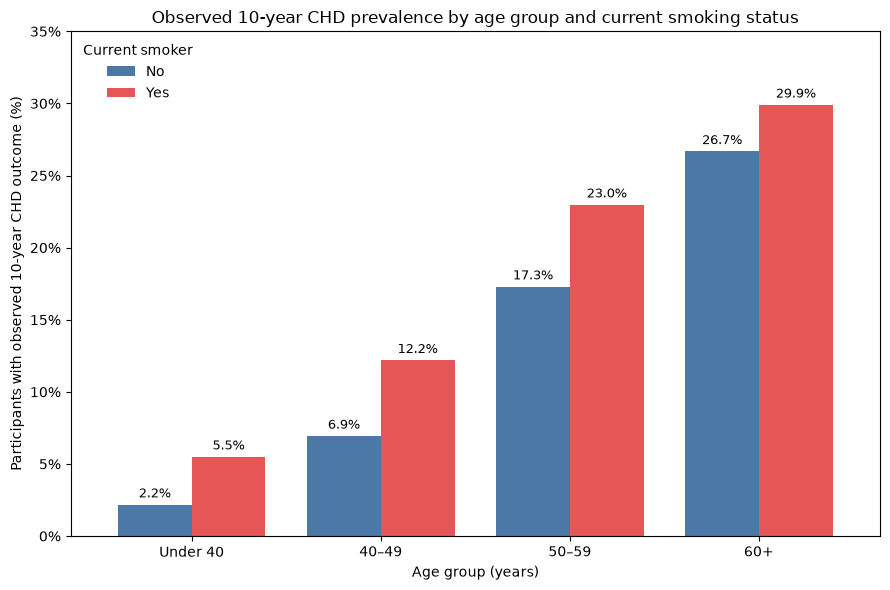

In [20]:
plot_data = summary.pivot(
    index="age_group",
    columns="smoking_status",
    values="chd_prevalence",
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#4C78A8", "#E45756"],
    width=0.78,
)

ax.set_title(
    "Observed 10-year CHD prevalence by age group and current smoking status"
)
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Participants with observed 10-year CHD outcome (%)")
ax.set_ylim(0, 0.35)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Current smoker", frameon=False)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.1f}%"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# Interpretation
The chart above shows the observed 10-year CHD prevalence by age group and current smoking status. The data shows that overall 10 year CHD was increasingly more prevelant for the older participants, prevalence ranged from 2.2-5.5% for participants under 40 and 26.7-29.9% for participants 60 or older. It also shows that within each age groups, the prevelance of CHD was higher for participants who are current smokers, the largest difference was 5.7 percentage points for participants who 50-59. 